### Notebook running Quantum State Tomography (QST) Algorithms
Algorithms implemented:
1) Maximum Likelihood Estimation (MLE)

In [1]:
# Import Packages
import numpy as np
import matplotlib.pyplot as plt

import qutip as q
from tqdm.notebook import tqdm

####################################################################
# Import utilities
import sys
from pathlib import Path

root = Path.cwd().resolve().parent
sys.path.insert(0, str(root))

from utilities.artificial_samples import cat, sqv, pssqv, spssqv, sample_homodyne
from utilities.MLE_class_original import MLE
from utilities.plotting import plot_dm, plot_Wigner, plot_fidelities

In [2]:
# Define target cat state parameters
N_cutoff = 50
parity = 0
theta = np.pi/4
alpha = np.sqrt(5)*np.exp(1j*theta)
# Generate target state
state = cat(N_cutoff, parity, alpha)

In [3]:
# Define target squeezed vacuum state parameters
N_cutoff = 50
r = 1.0
# Generate target state
state = sqv(N_cutoff, r)

In [4]:
# ON state parameters
N_cutoff = 50
n = 3
parity = 1
# Generate target state
ket = np.zeros(N_cutoff, dtype=complex)
ket[0] = 1/np.sqrt(2)
ket[n] = (-1)**parity / np.sqrt(2)
state = q.Qobj(ket)
rho = state.full()


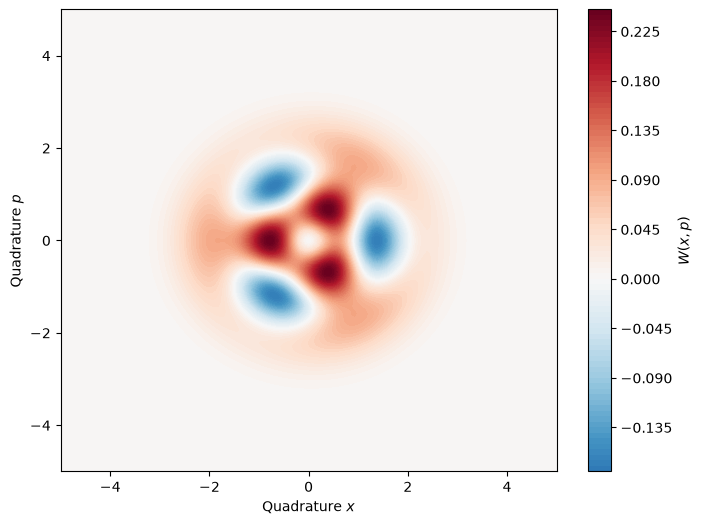

In [5]:
plot_Wigner(state)

In [6]:
# Define sampling parameters
N_angles = 8
N_samples_theta = 1000
x_range = (-5,5)
x_points = 400
x_array = np.linspace(x_range[0],x_range[1],x_points)
# Sample the selected state
thetas, samles = sample_homodyne(state=state,n_angles=N_angles,n_samples_theta=N_samples_theta,
                         bin_data=False,x_vec=x_array)

In [25]:
# Set MLE parameters
N_bins_array = np.arange(3, 50)
max_iter = 1000

rho_init = np.zeros((N_cutoff, N_cutoff), dtype=complex)
rho_init[0,0] = 1.0

# Arrays to store results
rhos = []
fidelities = []

# Initialize MLE estimator
MLE_estimator = MLE(data=samles, N_bins=N_bins_array[0], N_cutoff=N_cutoff)

for N_bins in N_bins_array:
    MLE_estimator.set_binning(N_bins)

    rho_current = rho_init
    rhos_bin = [rho_current]
    fidelities_bin = []
    rho_bin, fidelities_bin, rhos_bin = MLE_estimator.run_setpoint(threshold=1e-15,max_iter=max_iter,store_states=True)
    runs_bin = len(fidelities_bin)
    fid_bin = q.fidelity(q.Qobj(rho_bin),state)**2
    print(f'For {N_bins} bins: {runs_bin} iterations, f={fid_bin}')
    rhos.append(rhos_bin)
    fidelities.append(fidelities_bin)


For 3 bins: 1000 iterations, f=0.25178058694565947
For 4 bins: 553 iterations, f=0.9056604198875813
For 5 bins: 417 iterations, f=0.8521269348509963
For 6 bins: 308 iterations, f=0.9087866434354122
For 7 bins: 569 iterations, f=0.6941200526080686
For 8 bins: 288 iterations, f=0.9761294666751541
For 9 bins: 274 iterations, f=0.9438325000849346
For 10 bins: 170 iterations, f=0.9672127951878834
For 11 bins: 165 iterations, f=0.9192252862437494
For 12 bins: 169 iterations, f=0.9578971864327684
For 13 bins: 141 iterations, f=0.9279215574550316
For 14 bins: 169 iterations, f=0.9719576359831246
For 15 bins: 141 iterations, f=0.9691086544520788
For 16 bins: 105 iterations, f=0.9664859264623219
For 17 bins: 133 iterations, f=0.9377525726114415
For 18 bins: 129 iterations, f=0.9781259116325951
For 19 bins: 89 iterations, f=0.9687823590671265
For 20 bins: 118 iterations, f=0.9714847473504183
For 21 bins: 139 iterations, f=0.9762290649725273
For 22 bins: 122 iterations, f=0.9769724082446196
For 23

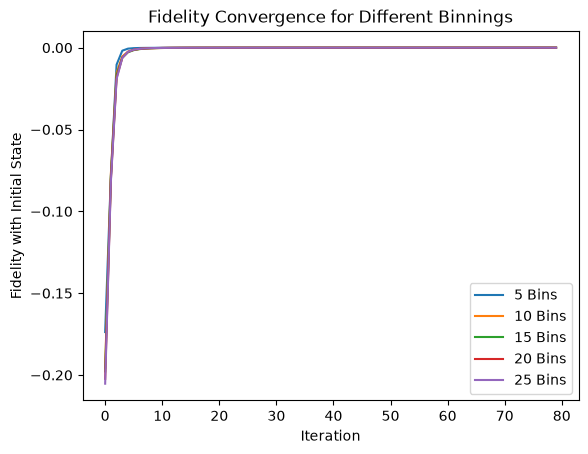

[[np.float64(0.6702730131171132), np.float64(0.8345756287215739), np.float64(0.9763881579681586), np.float64(0.9958224160310739), np.float64(0.9986816991725151), np.float64(0.999361475872441), np.float64(0.9996042397776045), np.float64(0.9997165306821034), np.float64(0.9997777016803833), np.float64(0.999815092280455), np.float64(0.9998400696361474), np.float64(0.9998580069409806), np.float64(0.9998716676043726), np.float64(0.9998825828606204), np.float64(0.999891636198636), np.float64(0.9998993757910212), np.float64(0.9999061334010427), np.float64(0.9999121418373513), np.float64(0.9999175558429523), np.float64(0.9999224732423686), np.float64(0.9999269690130127), np.float64(0.9999311183044627), np.float64(0.9999349676546213), np.float64(0.9999385098152417), np.float64(0.9999418203130149), np.float64(0.9999449058721857), np.float64(0.9999477594843075), np.float64(0.9999504363857568), np.float64(0.9999530176496968), np.float64(0.9999552838374797), np.float64(0.9999574805334063), np.float6

In [23]:
# Plot the fidelity convergence for each binning
for i, N_bins in enumerate(N_bins_array):
    plt.plot(np.log10(fidelities[i][:80]), label=f'{N_bins} Bins')
plt.xlabel('Iteration')
plt.ylabel('Fidelity with Initial State')
plt.title('Fidelity Convergence for Different Binnings')
plt.legend()
plt.show()
print(fidelities)

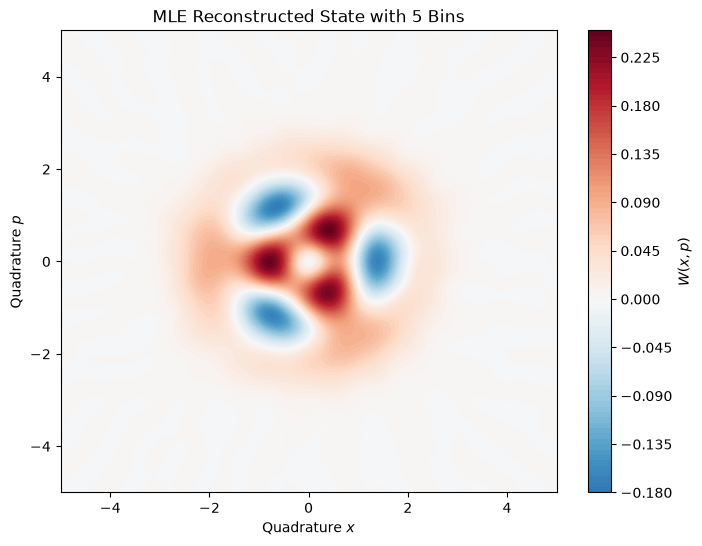

In [10]:
plot_Wigner(q.Qobj(rhos[1][-1]), xvec=x_array, title='MLE Reconstructed State with 5 Bins')

In [11]:
initial_rho = np.zeros((N_cutoff,N_cutoff))
initial_rho[0,0] = 1.0

rho_current = initial_rho
rhos = [rho_current]
fidelities = []
for i in tqdm(range(100)):
    rho_current = MLE_estimator.update_once(rho_current)
    rhos.append(rho_current)
    fidelities.append(q.fidelity(q.Qobj(rhos[-1]), q.Qobj(rhos[-2]))**2)
plot_Wigner(q.Qobj(rhos[-1]), xvec=x_array, title='MLE Reconstructed State')

  0%|          | 0/100 [00:00<?, ?it/s]

AttributeError: 'MLE' object has no attribute 'update_once'